In [218]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [219]:
import scipy 
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import os 
import h5py
from tqdm import tqdm
from joblib import Parallel, delayed
import timeit
from sympy import sin, cos, tan, Symbol, symbols, Matrix
from sympy.physics.vector import cross
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
from scipy.optimize import fsolve, least_squares, root_scalar
from scipy.integrate import odeint
from sympy import symbols, Eq, solve
from scipy.interpolate import interp1d
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.gridspec import GridSpec
from scipy.interpolate import CubicSpline
from scipy.optimize import differential_evolution
from scipy.optimize import minimize
from scipy.optimize import Bounds
from scipy.spatial import KDTree
from IPython.display import Image, display

<center>

### Setup del problem

In [220]:
t = symbols('t')
theta1, theta2, theta3 = dynamicsymbols('theta, beta, gamma')
N = ReferenceFrame('N') #normal (x,y tradicional)
A = N.orientnew('A', 'Axis', (theta1, N.z))
B = N.orientnew('B', 'Axis', (smp.pi-theta2, N.z))
C = N.orientnew('C', 'Axis', (theta3, N.z))

Ra, Rb, L1, L2 = symbols('Ra, Rb, L1, L2')
params = {Ra:9, Rb:10, L1:27, L2:27}

r1 = Ra*B.x
r2 = L2*N.x
r3 = Rb*C.x
# r4 = -r3-r2+r1
loop1 = -r1+r2+r3
loop1x = loop1.dot(N.x).subs(params)
loop1y = loop1.dot(N.y).subs(params)

r5 = L1*N.x
r6 = Ra*A.x
# r7 = -r3+r5+r6
loop2 = -r3+r5+r6
loop2x = loop2.dot(N.x).subs(params)
loop2y = loop2.dot(N.y).subs(params)

In [221]:
theta1_vals = np.linspace(0,2*np.pi,361)
theta2_vals = np.linspace(np.pi,-1*np.pi,361)

A_ = Ra*Rb*(smp.cos(theta1-theta2)) + Rb*(L1+L2)
B_ = Ra*Rb*(smp.sin(theta1-theta2))
C_ = Ra*Ra*(smp.sin(theta1-theta2)) - Ra*(smp.sin(theta1)*L2 + smp.sin(theta2)*L1)
theta3_exp = (smp.asin((C_/smp.sqrt((A_*A_) + (B_*B_)))) - smp.atan(B_/A_)).subs(params)

theta3_fun = smp.lambdify((theta1, theta2), theta3_exp, 'numpy')
theta3_vals = theta3_fun(theta1_vals, theta2_vals)


In [222]:
# lambdify scalar expressions
loop1x_fun = smp.lambdify((theta1, theta2, theta3), loop1x, 'numpy')
loop1y_fun = smp.lambdify((theta1, theta2, theta3), loop1y, 'numpy')

loop2x_fun = smp.lambdify((theta1, theta2, theta3), loop2x, 'numpy')
loop2y_fun = smp.lambdify((theta1, theta2, theta3), loop2y, 'numpy')

# evaluate
loop1x_vals = loop1x_fun(theta1_vals, theta2_vals, theta3_vals)
loop1y_vals = loop1y_fun(theta1_vals, theta2_vals, theta3_vals)
loop1_vals = np.hypot(loop1x_vals, loop1y_vals)

loop2x_vals = loop2x_fun(theta1_vals, theta2_vals, theta3_vals)
loop2y_vals = loop2y_fun(theta1_vals, theta2_vals, theta3_vals)
loop2_vals = np.hypot(loop2x_vals, loop2y_vals)

loop1_min = np.min(loop1_vals)
loop1_max = np.max(loop1_vals)

loop2_min = np.min(loop2_vals)
loop2_max = np.max(loop2_vals)

d2 = float(loop1_max - loop1_min)
d1 = float(loop2_max - loop2_min)


In [223]:
d1, d2

(21.267885998397677, 18.0)

In [224]:
import pandas as pd
import numpy as np

FILE_PATH = "/Users/camilauribequintero/Desktop/fish_parts.xlsx"
SHEET_NAME = 0

def smart_parse(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    s = str(x).strip()
    if s == "":
        return np.nan

    if "." in s and "," in s:      # 6.511,164 -> 6511.164
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:                 # 0,333 -> 0.333
        s = s.replace(",", ".")

    return float(s)

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df.columns = [c.strip() for c in df.columns]

numeric_cols = [
    "Mass [g]", "Volume [mm3]",
    "x_cm [mm]", "y_cm [mm]", "z_cm [mm]",
    "active [0/1]"
]

for col in numeric_cols:
    df[col] = df[col].apply(smart_parse)

df = df[df["active [0/1]"] == 1].copy()

# If any mass is empty, set it to 0 for now
df["Mass [g]"] = df["Mass [g]"].fillna(0)

total_mass_g = df["Mass [g]"].sum()

x_cg = (df["Mass [g]"] * df["x_cm [mm]"]).sum() / total_mass_g
y_cg = (df["Mass [g]"] * df["y_cm [mm]"]).sum() / total_mass_g
z_cg = (df["Mass [g]"] * df["z_cm [mm]"]).sum() / total_mass_g

print(f"Total mass = {total_mass_g:.3f} g")
print(f"CoG = ({x_cg:.3f}, {y_cg:.3f}, {z_cg:.3f}) mm")

Total mass = 1200.940 g
CoG = (171.822, 0.000, 12.753) mm


In [225]:
FILE_PATH = "/Users/camilauribequintero/Desktop/fish_parts.xlsx"
SHEET_NAME = 0

RHO_WATER = 1000.0   # kg/m^3
G = 9.81

def smart_parse(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    s = str(x).strip()
    if s == "":
        return np.nan

    if "." in s and "," in s:      # 6.511,164 -> 6511.164
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:                 # 0,333 -> 0.333
        s = s.replace(",", ".")

    return float(s)

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df.columns = [c.strip() for c in df.columns]

numeric_cols = [
    "Mass [g]", "Volume [mm3]",
    "x_cm [mm]", "y_cm [mm]", "z_cm [mm]",
    "active [0/1]"
]

for col in numeric_cols:
    df[col] = df[col].apply(smart_parse)

df = df[df["active [0/1]"] == 1].copy()
df["Mass [g]"] = df["Mass [g]"].fillna(0)
df["Kind"] = df["Kind"].fillna("").astype(str).str.strip()

# -----------------
# 1) MASS / CoG
# -----------------
total_mass_g = df["Mass [g]"].sum()
total_mass_kg = total_mass_g / 1000.0

x_cg = (df["Mass [g]"] * df["x_cm [mm]"]).sum() / total_mass_g
y_cg = (df["Mass [g]"] * df["y_cm [mm]"]).sum() / total_mass_g
z_cg = (df["Mass [g]"] * df["z_cm [mm]"]).sum() / total_mass_g

# -----------------
# 2) BUOYANCY / CoB
# -----------------
# For now: solids + sealed air volumes displace water
buoy_df = df[df["Kind"].isin(["solid", "sealed_air_volume"])].copy()

total_disp_mm3 = buoy_df["Volume [mm3]"].sum()
total_disp_m3 = total_disp_mm3 * 1e-9

x_cb = (buoy_df["Volume [mm3]"] * buoy_df["x_cm [mm]"]).sum() / total_disp_mm3
y_cb = (buoy_df["Volume [mm3]"] * buoy_df["y_cm [mm]"]).sum() / total_disp_mm3
z_cb = (buoy_df["Volume [mm3]"] * buoy_df["z_cm [mm]"]).sum() / total_disp_mm3

# -----------------
# 3) FORCES
# -----------------
weight_N = total_mass_kg * G
buoyant_force_N = RHO_WATER * G * total_disp_m3
net_force_N = buoyant_force_N - weight_N

equivalent_supported_mass_g = total_disp_m3 * RHO_WATER * 1000.0

print("=== MASS ===")
print(f"Total mass = {total_mass_g:.3f} g")
print(f"CoG = ({x_cg:.3f}, {y_cg:.3f}, {z_cg:.3f}) mm")

print("\n=== BUOYANCY ===")
print(f"Total displaced volume = {total_disp_mm3:.3f} mm^3")
print(f"Total displaced volume = {total_disp_m3:.9f} m^3")
print(f"CoB = ({x_cb:.3f}, {y_cb:.3f}, {z_cb:.3f}) mm")

print("\n=== FLOATATION ===")
print(f"Weight = {weight_N:.4f} N")
print(f"Buoyant force = {buoyant_force_N:.4f} N")
print(f"Net force = {net_force_N:.4f} N")

if net_force_N > 0:
    print("Result: positively buoyant")
elif net_force_N < 0:
    print("Result: negatively buoyant")
else:
    print("Result: neutral buoyancy")

print(f"Equivalent supported mass by displacement = {equivalent_supported_mass_g:.3f} g")
print(f"Mass difference = {equivalent_supported_mass_g - total_mass_g:.3f} g")

=== MASS ===
Total mass = 1200.940 g
CoG = (171.822, 0.000, 12.753) mm

=== BUOYANCY ===
Total displaced volume = 239759.905 mm^3
Total displaced volume = 0.000239760 m^3
CoB = (1833.964, 4.567, 12.812) mm

=== FLOATATION ===
Weight = 11.7812 N
Buoyant force = 2.3520 N
Net force = -9.4292 N
Result: negatively buoyant
Equivalent supported mass by displacement = 239.760 g
Mass difference = -961.180 g


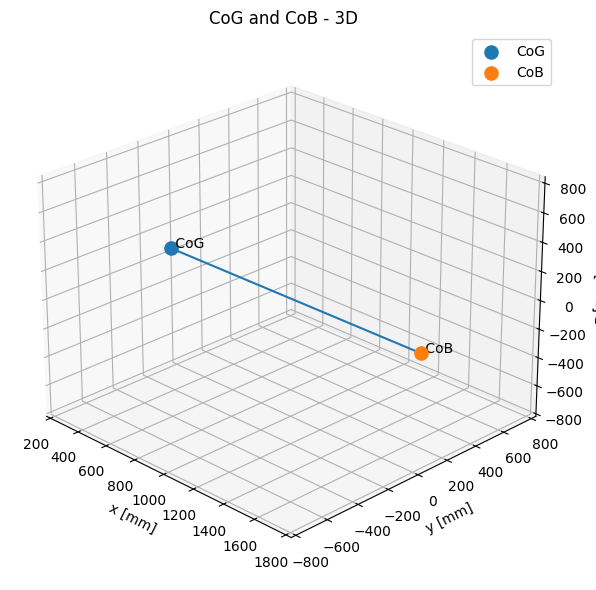

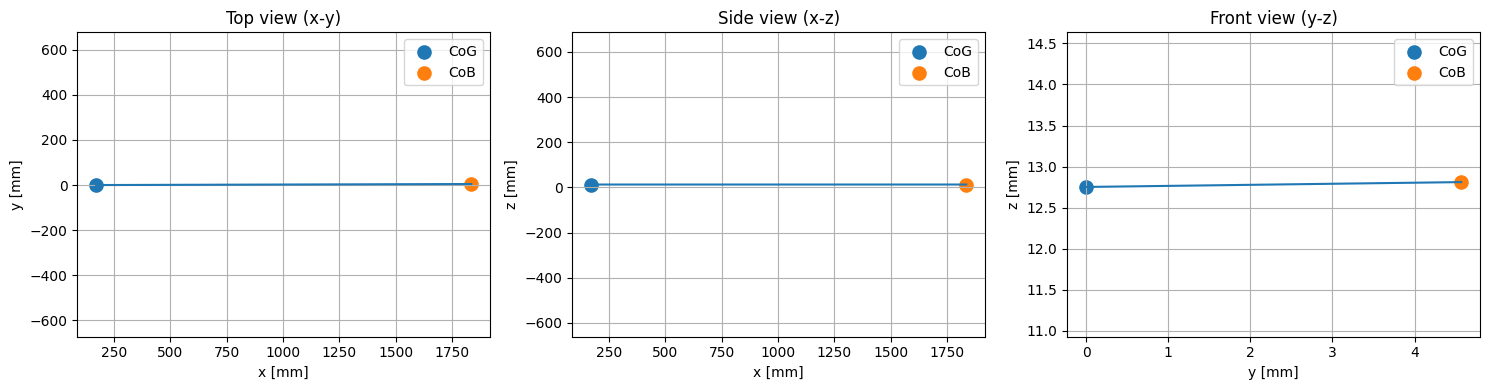

In [227]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Replace with your values
cog = np.array([x_cg, y_cg, z_cg])
cob = np.array([x_cb, y_cb, z_cb])

# -----------------------
# 3D plot
# -----------------------
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(*cog, s=90, label='CoG')
ax.scatter(*cob, s=90, label='CoB')

ax.plot(
    [cog[0], cob[0]],
    [cog[1], cob[1]],
    [cog[2], cob[2]],
    linewidth=1.5
)

ax.text(*cog, ' CoG')
ax.text(*cob, ' CoB')

ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_zlabel('z [mm]')
ax.set_title('CoG and CoB - 3D')

# Equal box
points = np.vstack([cog, cob])
mins = points.min(axis=0)
maxs = points.max(axis=0)
center = (mins + maxs) / 2
span = max(maxs - mins)
if span < 1:
    span = 1

ax.set_xlim(center[0] - span/2, center[0] + span/2)
ax.set_ylim(center[1] - span/2, center[1] + span/2)
ax.set_zlim(center[2] - span/2, center[2] + span/2)

# isometric-ish view
ax.view_init(elev=25, azim=-45)

ax.legend()
plt.tight_layout()
plt.show()


# -----------------------
# 2D orthographic views
# -----------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# 1) Top view: x-y
axs[0].scatter(cog[0], cog[1], s=90, label='CoG')
axs[0].scatter(cob[0], cob[1], s=90, label='CoB')
axs[0].plot([cog[0], cob[0]], [cog[1], cob[1]])
axs[0].set_xlabel('x [mm]')
axs[0].set_ylabel('y [mm]')
axs[0].set_title('Top view (x-y)')
axs[0].grid(True)
axs[0].axis('equal')
axs[0].legend()

# 2) Side view: x-z
axs[1].scatter(cog[0], cog[2], s=90, label='CoG')
axs[1].scatter(cob[0], cob[2], s=90, label='CoB')
axs[1].plot([cog[0], cob[0]], [cog[2], cob[2]])
axs[1].set_xlabel('x [mm]')
axs[1].set_ylabel('z [mm]')
axs[1].set_title('Side view (x-z)')
axs[1].grid(True)
axs[1].axis('equal')
axs[1].legend()

# 3) Front view: y-z
axs[2].scatter(cog[1], cog[2], s=90, label='CoG')
axs[2].scatter(cob[1], cob[2], s=90, label='CoB')
axs[2].plot([cog[1], cob[1]], [cog[2], cob[2]])
axs[2].set_xlabel('y [mm]')
axs[2].set_ylabel('z [mm]')
axs[2].set_title('Front view (y-z)')
axs[2].grid(True)
axs[2].axis('equal')
axs[2].legend()

plt.tight_layout()
plt.show()

#### Calculos para el control 

In [ ]:
#formulas del paper
def print_paper_formulas():
    print("\n=== FORMULAS FROM THE PAPER ===")
    print("Motor inputs: theta1, theta2, omega1, omega2")
    print("Reel output: theta3")
    print()
    print("Eq. (2):")
    print("theta3 = asin(C / sqrt(A^2 + B^2)) - atan(B / A)")
    print("A = Ra*Rb*(cos(theta1) - cos(theta2)) + Rb*(L1 + L2)")
    print("B = Ra*Rb*(sin(theta2) - sin(theta1))")
    print("C = Ra^2*sin(theta1 - theta2) - Ra*(sin(theta1)*L2 + sin(theta2)*L1)")
    print()
    print("Wire/reel displacement approximation:")
    print("wire_displacement = Rb * theta3")
    print("where theta3 is in radians and Rb is in mm.")
    print()
    print("Simple motor frequency relation:")
    print("omega = 2*pi*f")
    print("rpm = 60*f")
    print()
    print("Paper-based simple velocity estimate:")
    print("v_est ≈ 0.32 * f")
    print("because the paper reported about 0.32 m/s at 1 Hz in symmetric forward swimming.")
    print("================================\n")
    

In [172]:
# GEOMETRY MODEL: theta1, theta2 -> theta3

def calculate_theta3(theta1, theta2, Ra, Rb, L1, L2):
    """
    Implements Eq. (2) from the paper.
    
    Inputs:
    theta1, theta2 in radians
    Ra, Rb, L1, L2 in mm
    
    Output:
    theta3 in radians
    """
    
    A = Ra * Rb * (np.cos(theta1) - np.cos(theta2)) + Rb * (L1 + L2)
    B = Ra * Rb * (np.sin(theta2) - np.sin(theta1))
    C = (Ra**2) * np.sin(theta1 - theta2) - Ra * (np.sin(theta1) * L2 + np.sin(theta2) * L1)
    
    denominator = np.sqrt(A**2 + B**2)
    argument = C / denominator
    
    # Protect against tiny numerical errors outside [-1, 1]
    argument_clipped = np.clip(argument, -1, 1)
    
    theta3 = np.arcsin(argument_clipped) - np.arctan2(B, A)
    
    return theta3

# GENERAL ANALYSIS FUNCTION
def summarize_reel_motion(theta3, Rb, frequency_hz, reference_amp_deg=None, label=""):
    """
    Summarizes reel motion:
    - min/max angle
    - angular amplitude
    - peak-to-peak angle
    - wire displacement amplitude
    - simple estimated speed
    """
    
    theta3_deg = np.rad2deg(theta3)
    
    theta3_min_deg = np.min(theta3_deg)
    theta3_max_deg = np.max(theta3_deg)
    theta3_mean_deg = 0.5 * (theta3_max_deg + theta3_min_deg)
    theta3_amp_deg = 0.5 * (theta3_max_deg - theta3_min_deg)
    theta3_pp_deg = theta3_max_deg - theta3_min_deg
    
    theta3_amp_rad = np.deg2rad(theta3_amp_deg)
    theta3_pp_rad = np.deg2rad(theta3_pp_deg)
    
    wire_amp_mm = Rb * theta3_amp_rad
    wire_pp_mm = Rb * theta3_pp_rad
    
    # Simple paper-based estimate:
    # paper prototype: 0.32 m/s at 1 Hz in symmetric mode
    v_simple = 0.32 * frequency_hz
    
    # Optional amplitude-scaled estimate
    if reference_amp_deg is not None and reference_amp_deg > 0:
        v_amp_scaled = v_simple * (theta3_amp_deg / reference_amp_deg)
    else:
        v_amp_scaled = None
    
    print(f"\n=== {label} ===")
    print(f"frequency f = {frequency_hz:.3f} Hz")
    print(f"theta3_min = {theta3_min_deg:.3f} deg")
    print(f"theta3_max = {theta3_max_deg:.3f} deg")
    print(f"theta3_mean = {theta3_mean_deg:.3f} deg")
    print(f"theta3_amplitude = ±{theta3_amp_deg:.3f} deg")
    print(f"theta3_peak_to_peak = {theta3_pp_deg:.3f} deg")
    print()
    print(f"wire_displacement_amplitude = ±{wire_amp_mm:.3f} mm")
    print(f"wire_displacement_peak_to_peak = {wire_pp_mm:.3f} mm")
    print()
    print(f"simple paper velocity estimate: v ≈ {v_simple:.4f} m/s")
    
    if v_amp_scaled is not None:
        print(f"amplitude-scaled velocity estimate: v ≈ {v_amp_scaled:.4f} m/s")
    
    return {
        "theta3_min_deg": theta3_min_deg,
        "theta3_max_deg": theta3_max_deg,
        "theta3_mean_deg": theta3_mean_deg,
        "theta3_amp_deg": theta3_amp_deg,
        "theta3_pp_deg": theta3_pp_deg,
        "wire_amp_mm": wire_amp_mm,
        "wire_pp_mm": wire_pp_mm,
        "v_simple_m_s": v_simple,
        "v_amp_scaled_m_s": v_amp_scaled
    }

In [176]:
# SYMMETRIC MODE
def symmetric_mode(Ra, Rb, L1, L2, frequency_hz, samples=2000):
    """
    Symmetric mode from the paper:
    
    theta1 = theta2
    omega1 = omega2 = 2*pi*f
    
    This is the main forward-swimming mode.
    """
    
    theta_motor = np.linspace(0, 2*np.pi, samples)
    
    theta1 = theta_motor
    theta2 = theta_motor
    
    theta3 = calculate_theta3(theta1, theta2, Ra, Rb, L1, L2)
    
    omega = 2 * np.pi * frequency_hz
    rpm = 60 * frequency_hz
    
    print("SYMMETRIC MODE")
    print("Condition:")
    print("theta1 = theta2")
    print("omega1 = omega2 = 2*pi*f")
    print()
    print(f"omega1 = omega2 = {omega:.4f} rad/s")
    print(f"rpm1 = rpm2 = {rpm:.2f} rpm")
    
    result = summarize_reel_motion(
        theta3=theta3,
        Rb=Rb,
        frequency_hz=frequency_hz,
        reference_amp_deg=None,
        label="SYMMETRIC REEL OUTPUT"
    )
    
    result["omega1_rad_s"] = omega
    result["omega2_rad_s"] = omega
    result["rpm1"] = rpm
    result["rpm2"] = rpm
    
    return result

# ASYMMETRIC MODE

def asymmetric_mode(
    Ra, Rb, L1, L2,
    frequency_hz,
    fixed_motor=1,
    fixed_angle_deg=0,
    reference_amp_deg=None,
    samples=2000
):
    """
    Asymmetric mode:
    
    One motor is fixed at fixed_angle_deg.
    The other motor rotates continuously.
    
    fixed_motor = 1 means:
        theta1 = fixed_angle
        theta2 rotates
    
    fixed_motor = 2 means:
        theta2 = fixed_angle
        theta1 rotates
    """
    
    theta_rotating = np.linspace(0, 2*np.pi, samples)
    theta_fixed = np.deg2rad(fixed_angle_deg)
    
    if fixed_motor == 1:
        theta1 = np.ones_like(theta_rotating) * theta_fixed
        theta2 = theta_rotating
        omega1 = 0
        omega2 = 2 * np.pi * frequency_hz
        rpm1 = 0
        rpm2 = 60 * frequency_hz
        mode_text = "Motor 1 fixed, Motor 2 rotating"
        
    elif fixed_motor == 2:
        theta1 = theta_rotating
        theta2 = np.ones_like(theta_rotating) * theta_fixed
        omega1 = 2 * np.pi * frequency_hz
        omega2 = 0
        rpm1 = 60 * frequency_hz
        rpm2 = 0
        mode_text = "Motor 2 fixed, Motor 1 rotating"
        
    else:
        raise ValueError("fixed_motor must be 1 or 2")
    
    theta3 = calculate_theta3(theta1, theta2, Ra, Rb, L1, L2)
    
    print("ASYMMETRIC MODE")
    print("Condition:")
    print(mode_text)
    print(f"fixed_angle = {fixed_angle_deg:.3f} deg")
    print()
    print(f"omega1 = {omega1:.4f} rad/s")
    print(f"omega2 = {omega2:.4f} rad/s")
    print(f"rpm1 = {rpm1:.2f} rpm")
    print(f"rpm2 = {rpm2:.2f} rpm")
    
    result = summarize_reel_motion(
        theta3=theta3,
        Rb=Rb,
        frequency_hz=frequency_hz,
        reference_amp_deg=reference_amp_deg,
        label="ASYMMETRIC REEL OUTPUT"
    )
    
    result["omega1_rad_s"] = omega1
    result["omega2_rad_s"] = omega2
    result["rpm1"] = rpm1
    result["rpm2"] = rpm2
    result["fixed_motor"] = fixed_motor
    result["fixed_angle_deg"] = fixed_angle_deg
    
    return result


In [177]:
# ============================================================
# YOUR CURRENT VALUES
# ============================================================

print_paper_formulas()

Ra = 9      # mm
Rb = 10     # mm
L1 = 27     # mm
L2 = 25     # mm

frequency_hz = 0.6


=== FORMULAS FROM THE PAPER ===
Motor inputs: theta1, theta2, omega1, omega2
Reel output: theta3

Eq. (2):
theta3 = asin(C / sqrt(A^2 + B^2)) - atan(B / A)
A = Ra*Rb*(cos(theta1) - cos(theta2)) + Rb*(L1 + L2)
B = Ra*Rb*(sin(theta2) - sin(theta1))
C = Ra^2*sin(theta1 - theta2) - Ra*(sin(theta1)*L2 + sin(theta2)*L1)

Wire/reel displacement approximation:
wire_displacement = Rb * theta3
where theta3 is in radians and Rb is in mm.

Simple motor frequency relation:
omega = 2*pi*f
rpm = 60*f

Paper-based simple velocity estimate:
v_est ≈ 0.32 * f
because the paper reported about 0.32 m/s at 1 Hz in symmetric forward swimming.



In [178]:
# 1) Symmetric mode
sym_result = symmetric_mode(
    Ra=Ra,
    Rb=Rb,
    L1=L1,
    L2=L2,
    frequency_hz=frequency_hz
)

# Use symmetric amplitude as reference for amplitude-scaled asymmetric velocity
reference_amp_deg = sym_result["theta3_amp_deg"]

# 2) Asymmetric mode example:
# Motor 1 fixed at 0 deg, Motor 2 rotating
asym_result = asymmetric_mode(
    Ra=Ra,
    Rb=Rb,
    L1=L1,
    L2=L2,
    frequency_hz=frequency_hz,
    fixed_motor=1,
    fixed_angle_deg=0,
    reference_amp_deg=reference_amp_deg
)

# 3) Optional: opposite asymmetric case
# Motor 2 fixed at 0 deg, Motor 1 rotating
asym_result_opposite = asymmetric_mode(
    Ra=Ra,
    Rb=Rb,
    L1=L1,
    L2=L2,
    frequency_hz=frequency_hz,
    fixed_motor=2,
    fixed_angle_deg=0,
    reference_amp_deg=reference_amp_deg
)

SYMMETRIC MODE
Condition:
theta1 = theta2
omega1 = omega2 = 2*pi*f

omega1 = omega2 = 3.7699 rad/s
rpm1 = rpm2 = 36.00 rpm

=== SYMMETRIC REEL OUTPUT ===
frequency f = 0.600 Hz
theta3_min = -64.158 deg
theta3_max = 64.158 deg
theta3_mean = 0.000 deg
theta3_amplitude = ±64.158 deg
theta3_peak_to_peak = 128.316 deg

wire_displacement_amplitude = ±11.198 mm
wire_displacement_peak_to_peak = 22.395 mm

simple paper velocity estimate: v ≈ 0.1920 m/s
ASYMMETRIC MODE
Condition:
Motor 1 fixed, Motor 2 rotating
fixed_angle = 0.000 deg

omega1 = 0.0000 rad/s
omega2 = 3.7699 rad/s
rpm1 = 0.00 rpm
rpm2 = 36.00 rpm

=== ASYMMETRIC REEL OUTPUT ===
frequency f = 0.600 Hz
theta3_min = -40.567 deg
theta3_max = 40.567 deg
theta3_mean = 0.000 deg
theta3_amplitude = ±40.567 deg
theta3_peak_to_peak = 81.135 deg

wire_displacement_amplitude = ±7.080 mm
wire_displacement_peak_to_peak = 14.161 mm

simple paper velocity estimate: v ≈ 0.1920 m/s
amplitude-scaled velocity estimate: v ≈ 0.1214 m/s
ASYMMETRIC MODE


In [181]:
duration = 5     # seconds
dt = 0.05        # seconds between commands

w = 2 * np.pi * f          # rad/s
w_deg_s = np.rad2deg(w)    # deg/s
rpm = 60 * f               # rpm

print("=== SYMMETRIC STRAIGHT-LINE MODE ===")
print(f"f = {f} Hz")
print(f"w1 = w2 = {w:.4f} rad/s")
print(f"w1 = w2 = {w_deg_s:.2f} deg/s")
print(f"rpm1 = rpm2 = {rpm:.2f} rpm")
print()

t_values = np.arange(0, duration + dt, dt)

# -----------------------------
# Generate motor angles
# -----------------------------
# angle_deg = 360*f*t
# Wrapped means it goes from 0 to 360, then starts again at 0.

theta1_deg = (360 * f * t_values) % 360
theta2_deg = (360 * f * t_values) % 360

# For checking reel angle with your paper equation
theta1_rad = np.deg2rad(theta1_deg)
theta2_rad = np.deg2rad(theta2_deg)

theta3_rad = calculate_theta3(theta1_rad, theta2_rad, Ra, Rb, L1, L2)
theta3_deg = np.rad2deg(theta3_rad)

# -----------------------------
# Create actual list of commands
# -----------------------------
# Format:
# (time, servo1_angle, servo2_angle, reel_angle)

servo_angle_commands = []

for i in range(len(t_values)):
    command = (
        round(float(t_values[i]), 3),
        round(float(theta1_deg[i]), 3),
        round(float(theta2_deg[i]), 3),
        round(float(theta3_deg[i]), 3)
    )
    servo_angle_commands.append(command)

# -----------------------------
# Print list
# -----------------------------

print("Format:")
print("(time_s, theta1_servo_deg, theta2_servo_deg, theta3_reel_deg)")
print()

#for command in servo_angle_commands:
    #print(command)


#Separate lists for servo angles 
theta1_list = theta1_deg.tolist()
theta2_list = theta2_deg.tolist()

print("\nOnly theta1 list:")
print([round(a, 3) for a in theta1_list])

print("\nOnly theta2 list:")
print([round(a, 3) for a in theta2_list])

=== SYMMETRIC STRAIGHT-LINE MODE ===
f = 0.6 Hz
w1 = w2 = 3.7699 rad/s
w1 = w2 = 216.00 deg/s
rpm1 = rpm2 = 36.00 rpm

Format:
(time_s, theta1_servo_deg, theta2_servo_deg, theta3_reel_deg)


Only theta1 list:
[0.0, 10.8, 21.6, 32.4, 43.2, 54.0, 64.8, 75.6, 86.4, 97.2, 108.0, 118.8, 129.6, 140.4, 151.2, 162.0, 172.8, 183.6, 194.4, 205.2, 216.0, 226.8, 237.6, 248.4, 259.2, 270.0, 280.8, 291.6, 302.4, 313.2, 324.0, 334.8, 345.6, 356.4, 7.2, 18.0, 28.8, 39.6, 50.4, 61.2, 72.0, 82.8, 93.6, 104.4, 115.2, 126.0, 136.8, 147.6, 158.4, 169.2, 180.0, 190.8, 201.6, 212.4, 223.2, 234.0, 244.8, 255.6, 266.4, 277.2, 288.0, 298.8, 309.6, 320.4, 331.2, 342.0, 352.8, 3.6, 14.4, 25.2, 36.0, 46.8, 57.6, 68.4, 79.2, 90.0, 100.8, 111.6, 122.4, 133.2, 144.0, 154.8, 165.6, 176.4, 187.2, 198.0, 208.8, 219.6, 230.4, 241.2, 252.0, 262.8, 273.6, 284.4, 295.2, 306.0, 316.8, 327.6, 338.4, 349.2, 0.0]

Only theta2 list:
[0.0, 10.8, 21.6, 32.4, 43.2, 54.0, 64.8, 75.6, 86.4, 97.2, 108.0, 118.8, 129.6, 140.4, 151.2, 16

### Asymmetric Mode

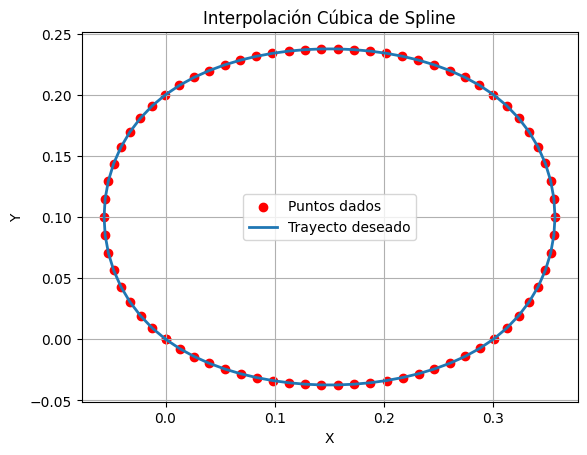

In [191]:
t = symbols('t')
x1s, x2s, x3s, x4s = symbols('x1s, x2s, x3s, x4s')
y1s, y2s, y3s, y4s = symbols('y1s, y2s, y3s, y4s')

listx = [x1s, x2s, x3s, x4s, x1s]
listy = [y1s, y2s, y3s, y4s, y1s]

params_p = {x1s: 0/1000, x2s: 300/1000, x3s: 300/1000, x4s: 0/1000, y1s: 0/1000, y2s: 0/100, y3s: 200/1000, y4s: 200/1000}
listx_subs = [float(xi.subs(params_p)) for xi in listx]
listy_subs = [float(yi.subs(params_p)) for yi in listy]

cs_x = CubicSpline(range(len(listx_subs)), listx_subs, bc_type='periodic')
cs_y = CubicSpline(range(len(listy_subs)), listy_subs, bc_type='periodic')

t_fine = np.linspace(0, len(listx_subs) - 1, 1000)
x_fine = cs_x(t_fine)
y_fine = cs_y(t_fine)

dx = np.diff(x_fine)
dy = np.diff(y_fine)
segment_lengths = np.sqrt(dx**2 + dy**2)
arc_length = np.concatenate([[0], np.cumsum(segment_lengths)])

n_samples = 75
arc_pos = np.linspace(0, arc_length[-1], n_samples)

interp_x = interp1d(arc_length, x_fine)
interp_y = interp1d(arc_length, y_fine)

x_ = interp_x(arc_pos)
y_ = interp_y(arc_pos)

evenly_spaced_points = list(zip(x_, y_))

plt.scatter(x_, y_, color='red', label="Puntos dados") 
plt.plot(x_, y_, label="Trayecto deseado", linestyle='-', linewidth=2)
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Interpolación Cúbica de Spline")
plt.grid()
plt.show()

    point_id       s_m  u_spline       x_m       y_m  heading_deg  \
0          0  0.000000  0.000000  0.000000  0.000000   -33.690068   
1          1  0.014933  0.054086  0.012805 -0.007673   -28.340841   
2          2  0.029866  0.106076  0.026220 -0.014223   -23.821578   
3          3  0.044800  0.156258  0.040080 -0.019776   -19.935094   
4          4  0.059733  0.204917  0.054264 -0.024439   -16.528145   
5          5  0.074666  0.252322  0.068688 -0.028298   -13.483228   
6          6  0.089599  0.298713  0.083289 -0.031422   -10.710390   
7          7  0.104532  0.344308  0.098020 -0.033864    -8.138971   
8          8  0.119465  0.389304  0.112844 -0.035662    -5.712364   
9          9  0.134399  0.433882  0.127729 -0.036844    -3.383142   
10        10  0.149332  0.478216  0.142650 -0.037428    -1.110006   
11        11  0.164265  0.522470  0.157582 -0.037424     1.144984   
12        12  0.179198  0.566806  0.172502 -0.036830     3.418695   
13        13  0.194131  0.611390  

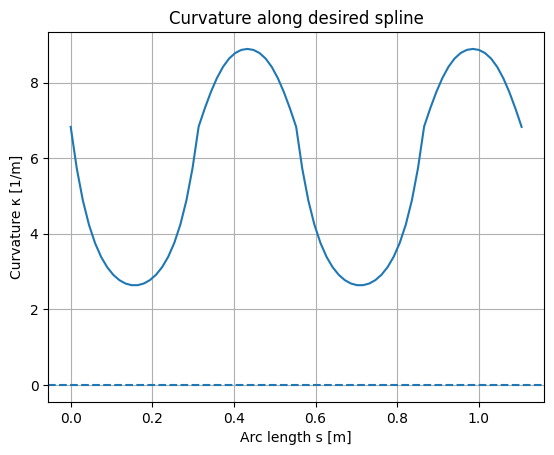

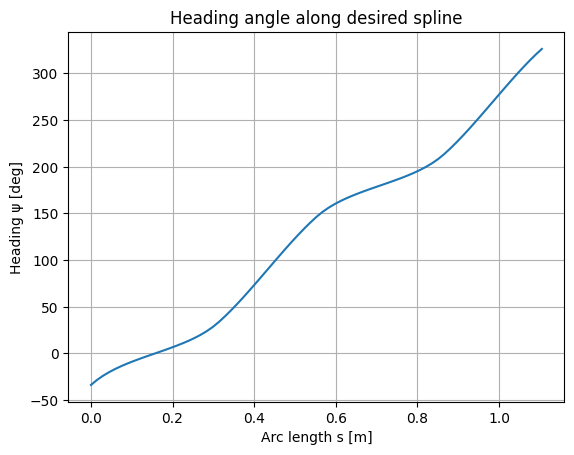

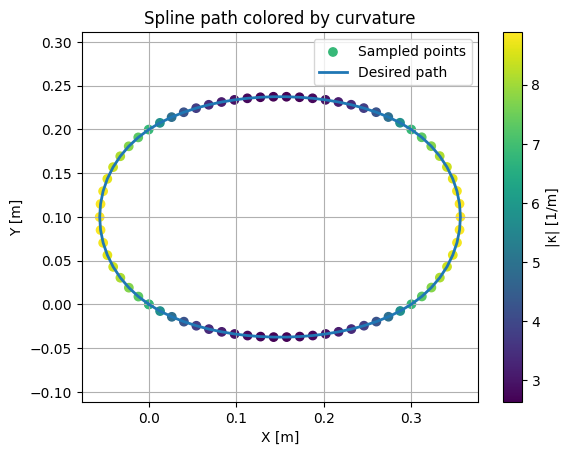

In [192]:
# ============================================================
# CURVATURE FROM YOUR SPLINE
# ============================================================

# We already have:
# cs_x, cs_y
# t_fine
# x_fine, y_fine
# arc_length
# arc_pos
# x_, y_

# 1. Convert each arc-length sample back to the spline parameter u
interp_u = interp1d(arc_length, t_fine, kind="linear", fill_value="extrapolate")
u_samples = interp_u(arc_pos)

# 2. First and second derivatives of the spline
dx_du = cs_x(u_samples, 1)
dy_du = cs_y(u_samples, 1)

d2x_du2 = cs_x(u_samples, 2)
d2y_du2 = cs_y(u_samples, 2)

# 3. Curvature formula
# kappa has units of 1/m because your x and y are in meters
denominator = (dx_du**2 + dy_du**2)**1.5

# Avoid division by zero
epsilon = 1e-9
denominator = np.where(denominator < epsilon, epsilon, denominator)

kappa = (dx_du * d2y_du2 - dy_du * d2x_du2) / denominator

# 4. Heading angle of the trajectory
psi = np.arctan2(dy_du, dx_du)
psi_unwrapped = np.unwrap(psi)
psi_deg = np.rad2deg(psi_unwrapped)

# 5. Turning radius
# R = 1 / |kappa|
radius = np.where(np.abs(kappa) > epsilon, 1 / np.abs(kappa), np.inf)

# 6. Save results in a table
curvature_table = pd.DataFrame({
    "point_id": np.arange(len(u_samples)),
    "s_m": arc_pos,
    "u_spline": u_samples,
    "x_m": x_,
    "y_m": y_,
    "heading_deg": psi_deg,
    "kappa_1_per_m": kappa,
    "turning_radius_m": radius
})

print(curvature_table.head(20))

print("\n=== CURVATURE SUMMARY ===")
print(f"min kappa = {np.min(kappa):.4f} 1/m")
print(f"max kappa = {np.max(kappa):.4f} 1/m")
print(f"max |kappa| = {np.max(np.abs(kappa)):.4f} 1/m")
print(f"minimum turning radius = {np.min(radius[np.isfinite(radius)]):.4f} m")

# 7. Plot curvature along the path
plt.figure()
plt.plot(arc_pos, kappa)
plt.axhline(0, linestyle="--")
plt.xlabel("Arc length s [m]")
plt.ylabel("Curvature κ [1/m]")
plt.title("Curvature along desired spline")
plt.grid()
plt.show()

# 8. Plot heading along the path
plt.figure()
plt.plot(arc_pos, psi_deg)
plt.xlabel("Arc length s [m]")
plt.ylabel("Heading ψ [deg]")
plt.title("Heading angle along desired spline")
plt.grid()
plt.show()

# 9. Plot path with curvature magnitude
plt.figure()
plt.scatter(x_, y_, c=np.abs(kappa), label="Sampled points")
plt.plot(x_, y_, linewidth=2, label="Desired path")
plt.colorbar(label="|κ| [1/m]")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Spline path colored by curvature")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

=== SPEED ESTIMATE ===
frequency_hz = 0.600 Hz
eta_v = 0.350
v_est = eta_v * 0.32 * f
v_est = 0.0672 m/s

=== YAW RATE ===
Formula:
yaw_rate_rad_s = v_est * kappa

min yaw_rate = 10.161 deg/s
max yaw_rate = 34.225 deg/s

=== FIXED MOTOR ANGLE BETA ===
Formula:
beta_deg = 90 * yaw_rate_deg_s / (eta_turn * 25.7 * frequency_hz)

eta_turn = 0.500
beta min before clamp = 118.607 deg
beta max before clamp = 399.510 deg
beta min after clamp = 118.607 deg
beta max after clamp = 360.000 deg
number of saturated points = 22 out of 75

=== COMMAND TABLE HEAD ===
    point_id       s_m  u_spline       x_m       y_m  heading_deg  \
0          0  0.000000  0.000000  0.000000  0.000000   -33.690068   
1          1  0.014933  0.054086  0.012805 -0.007673   -28.340841   
2          2  0.029866  0.106076  0.026220 -0.014223   -23.821578   
3          3  0.044800  0.156258  0.040080 -0.019776   -19.935094   
4          4  0.059733  0.204917  0.054264 -0.024439   -16.528145   
5          5  0.074666  0.252

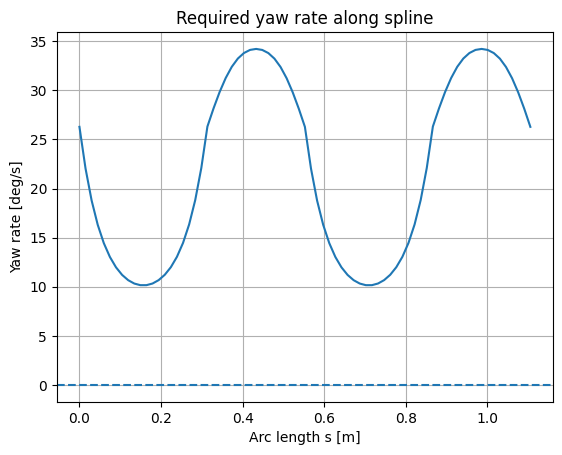

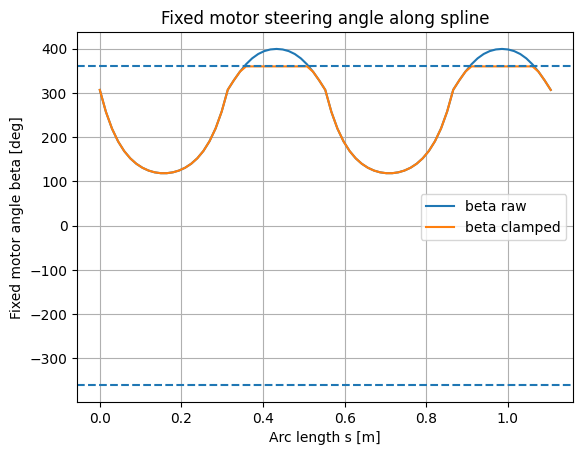

In [196]:
# ============================================================
# CURVATURE → YAW RATE → FIXED MOTOR ANGLE → SERVO COMMANDS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. USER INPUTS / ASSUMPTIONS
# ------------------------------------------------------------

frequency_hz = 0.6          # motor/tailbeat frequency
eta_v = 0.35                # velocity efficiency factor, 0 to 1
eta_turn = 0.50             # turning efficiency factor, 0 to 1

# Paper reference values
v_per_hz_paper = 0.32       # m/s at 1 Hz, from paper forward swimming
turn_rate_ref_deg_s = 25.7  # deg/s at beta = 90 deg and f = 1 Hz
beta_ref_deg = 90           # paper reference fixed motor angle
f_ref = 1.0                 # Hz

# Motor command limits
beta_max_deg = 360       # maximum fixed steering angle allowed

# Sign convention
# If positive beta makes your fish turn the wrong way, change this to -1
turn_sign = 1

# Asymmetric mode convention:
# rotating_motor = 1 means:
#   theta1 rotates
#   theta2 = beta
#
# rotating_motor = 2 means:
#   theta2 rotates
#   theta1 = beta
rotating_motor = 1

# ------------------------------------------------------------
# 2. ESTIMATED FORWARD VELOCITY
# ------------------------------------------------------------
# The paper approximation is:
# v ≈ 0.32 * f
#
# We reduce it using eta_v because your prototype may be slower.

v_est = eta_v * v_per_hz_paper * frequency_hz

print("=== SPEED ESTIMATE ===")
print(f"frequency_hz = {frequency_hz:.3f} Hz")
print(f"eta_v = {eta_v:.3f}")
print(f"v_est = eta_v * 0.32 * f")
print(f"v_est = {v_est:.4f} m/s")

# ------------------------------------------------------------
# 3. TIME ALONG THE PATH
# ------------------------------------------------------------
# Since s_m is distance along the spline:
# time = distance / velocity

s_m = curvature_table["s_m"].to_numpy()
kappa = curvature_table["kappa_1_per_m"].to_numpy()

if v_est <= 0:
    raise ValueError("v_est must be greater than zero.")

time_s = s_m / v_est

# ------------------------------------------------------------
# 4. CURVATURE TO YAW RATE
# ------------------------------------------------------------
# yaw_rate = v * kappa
#
# Units:
# v       = m/s
# kappa   = 1/m
# yaw_rate = rad/s

yaw_rate_rad_s = v_est * kappa
yaw_rate_deg_s = np.rad2deg(yaw_rate_rad_s)

print("\n=== YAW RATE ===")
print("Formula:")
print("yaw_rate_rad_s = v_est * kappa")
print()
print(f"min yaw_rate = {np.min(yaw_rate_deg_s):.3f} deg/s")
print(f"max yaw_rate = {np.max(yaw_rate_deg_s):.3f} deg/s")

# ------------------------------------------------------------
# 5. YAW RATE TO FIXED MOTOR ANGLE BETA
# ------------------------------------------------------------
# Approximation from paper:
#
# yaw_rate_deg_s ≈ eta_turn * 25.7 * (beta_deg / 90) * (f / 1)
#
# Solving:
#
# beta_deg ≈ 90 * yaw_rate_deg_s / (eta_turn * 25.7 * f)

denominator = eta_turn * turn_rate_ref_deg_s * (frequency_hz / f_ref)

if denominator <= 0:
    raise ValueError("eta_turn and frequency_hz must be greater than zero.")

beta_raw_deg = turn_sign * beta_ref_deg * yaw_rate_deg_s / denominator

# Clamp beta so it stays within physical limits
beta_cmd_deg = np.clip(beta_raw_deg, -beta_max_deg, beta_max_deg)

beta_saturated = np.abs(beta_raw_deg) > beta_max_deg

print("\n=== FIXED MOTOR ANGLE BETA ===")
print("Formula:")
print("beta_deg = 90 * yaw_rate_deg_s / (eta_turn * 25.7 * frequency_hz)")
print()
print(f"eta_turn = {eta_turn:.3f}")
print(f"beta min before clamp = {np.min(beta_raw_deg):.3f} deg")
print(f"beta max before clamp = {np.max(beta_raw_deg):.3f} deg")
print(f"beta min after clamp = {np.min(beta_cmd_deg):.3f} deg")
print(f"beta max after clamp = {np.max(beta_cmd_deg):.3f} deg")
print(f"number of saturated points = {np.sum(beta_saturated)} out of {len(beta_saturated)}")

# ------------------------------------------------------------
# 6. ROTATING MOTOR ANGLE
# ------------------------------------------------------------
# The rotating motor angle is:
#
# theta_rotating = 360 * f * time
#
# Wrapped version is from 0 to 360 deg.
# Unwrapped version keeps accumulating.

theta_rotating_unwrapped_deg = 360 * frequency_hz * time_s
theta_rotating_wrapped_deg = theta_rotating_unwrapped_deg % 360

# ------------------------------------------------------------
# 7. ASSIGN THETA1 AND THETA2
# ------------------------------------------------------------

if rotating_motor == 1:
    theta1_unwrapped_deg = theta_rotating_unwrapped_deg
    theta1_wrapped_deg = theta_rotating_wrapped_deg

    theta2_unwrapped_deg = beta_cmd_deg
    theta2_wrapped_deg = beta_cmd_deg

elif rotating_motor == 2:
    theta1_unwrapped_deg = beta_cmd_deg
    theta1_wrapped_deg = beta_cmd_deg

    theta2_unwrapped_deg = theta_rotating_unwrapped_deg
    theta2_wrapped_deg = theta_rotating_wrapped_deg

else:
    raise ValueError("rotating_motor must be 1 or 2.")

# ------------------------------------------------------------
# 8. CREATE COMMAND TABLE
# ------------------------------------------------------------

command_table = curvature_table.copy()

command_table["time_s"] = time_s
command_table["frequency_hz"] = frequency_hz
command_table["v_est_m_s"] = v_est
command_table["yaw_rate_rad_s"] = yaw_rate_rad_s
command_table["yaw_rate_deg_s"] = yaw_rate_deg_s
command_table["beta_raw_deg"] = beta_raw_deg
command_table["beta_cmd_deg"] = beta_cmd_deg
command_table["beta_saturated"] = beta_saturated

command_table["theta1_cmd_deg_wrapped"] = theta1_wrapped_deg
command_table["theta2_cmd_deg_wrapped"] = theta2_wrapped_deg
command_table["theta1_cmd_deg_unwrapped"] = theta1_unwrapped_deg
command_table["theta2_cmd_deg_unwrapped"] = theta2_unwrapped_deg

print("\n=== COMMAND TABLE HEAD ===")
print(command_table.head(20))

# Save command table
command_table.to_csv("spline_to_asymmetric_motor_commands.csv", index=False)
print("\nSaved: spline_to_asymmetric_motor_commands.csv")

# ------------------------------------------------------------
# 9. PLOTS
# ------------------------------------------------------------

plt.figure()
plt.plot(command_table["s_m"], command_table["yaw_rate_deg_s"])
plt.axhline(0, linestyle="--")
plt.xlabel("Arc length s [m]")
plt.ylabel("Yaw rate [deg/s]")
plt.title("Required yaw rate along spline")
plt.grid()
plt.show()

plt.figure()
plt.plot(command_table["s_m"], command_table["beta_raw_deg"], label="beta raw")
plt.plot(command_table["s_m"], command_table["beta_cmd_deg"], label="beta clamped")
plt.axhline(beta_max_deg, linestyle="--")
plt.axhline(-beta_max_deg, linestyle="--")
plt.xlabel("Arc length s [m]")
plt.ylabel("Fixed motor angle beta [deg]")
plt.title("Fixed motor steering angle along spline")
plt.legend()
plt.grid()
plt.show()

# plt.figure()
# plt.plot(command_table["s_m"], command_table["theta1_cmd_deg_wrapped"], label="theta1 wrapped")
# plt.plot(command_table["s_m"], command_table["theta2_cmd_deg_wrapped"], label="theta2 wrapped")
# plt.xlabel("Arc length s [m]")
# plt.ylabel("Motor command angle [deg]")
# plt.title("Motor angle commands along spline")
# plt.legend()
# plt.grid()
# plt.show()

# plt.figure()
# plt.scatter(
#     command_table["x_m"],
#     command_table["y_m"],
#     c=command_table["beta_cmd_deg"]
# )
# plt.plot(command_table["x_m"], command_table["y_m"], linewidth=2)
# plt.colorbar(label="beta_cmd_deg")
# plt.xlabel("X [m]")
# plt.ylabel("Y [m]")
# plt.title("Path colored by fixed motor angle beta")
# plt.axis("equal")
# plt.grid()
# plt.show()

=== THETA1 / THETA2 COMMAND LIST ===
Format: (time_s, theta1_deg, theta2_deg)

(0.0, 0.0, 306.842)
(0.222, 47.999, 257.27)
(0.444, 95.999, 219.247)
(0.667, 143.998, 190.39)
(0.889, 191.998, 168.564)
(1.111, 239.997, 152.111)
(1.333, 287.997, 139.818)
(1.556, 335.996, 130.823)
(1.778, 23.996, 124.528)
(2.0, 71.995, 120.537)
(2.222, 119.995, 118.607)
(2.444, 167.994, 118.621)
(2.667, 215.994, 120.583)
(2.889, 263.993, 124.608)
(3.111, 311.993, 130.94)
(3.333, 359.992, 139.981)
(3.556, 47.992, 152.332)
(3.778, 95.991, 168.858)
(4.0, 143.991, 190.779)
(4.222, 191.99, 219.76)
(4.444, 239.99, 257.944)
(4.667, 287.989, 307.185)
(4.889, 335.989, 328.669)
(5.111, 23.988, 348.186)
(5.333, 71.988, 360.0)
(5.555, 119.987, 360.0)
(5.778, 167.987, 360.0)
(6.0, 215.986, 360.0)
(6.222, 263.986, 360.0)
(6.444, 311.985, 360.0)
(6.667, 359.985, 360.0)
(6.889, 47.984, 360.0)
(7.111, 95.984, 360.0)
(7.333, 143.983, 360.0)
(7.555, 191.983, 360.0)
(7.778, 239.982, 347.903)
(8.0, 287.982, 328.349)
(8.222, 335

In [199]:
# ============================================================
# ASYMMETRIC MODE COMMAND LIST
# rotating motor gets angular velocity
# fixed/steering motor gets angle beta
# ============================================================

# Assumes you already have command_table from the previous block

frequency_hz = 0.6

omega_rotating_rad_s = 2 * np.pi * frequency_hz
omega_rotating_deg_s = np.rad2deg(omega_rotating_rad_s)
rpm_rotating = 60 * frequency_hz

rotating_motor = 1  # motor 1 rotates, motor 2 steers

asym_command_table = command_table[[
    "point_id",
    "time_s",
    "x_m",
    "y_m",
    "heading_deg",
    "kappa_1_per_m",
    "yaw_rate_deg_s",
    "beta_cmd_deg",
    "beta_saturated"
]].copy()

if rotating_motor == 1:
    asym_command_table["omega1_rad_s"] = omega_rotating_rad_s
    asym_command_table["rpm1"] = rpm_rotating
    asym_command_table["theta2_beta_deg"] = asym_command_table["beta_cmd_deg"]

    asym_command_table["omega2_rad_s"] = 0.0
    asym_command_table["rpm2"] = 0.0

elif rotating_motor == 2:
    asym_command_table["omega2_rad_s"] = omega_rotating_rad_s
    asym_command_table["rpm2"] = rpm_rotating
    asym_command_table["theta1_beta_deg"] = asym_command_table["beta_cmd_deg"]

    asym_command_table["omega1_rad_s"] = 0.0
    asym_command_table["rpm1"] = 0.0

print("=== ASYMMETRIC COMMAND TABLE ===")
print(f"frequency = {frequency_hz:.3f} Hz")
print(f"omega rotating = {omega_rotating_rad_s:.4f} rad/s")
print(f"omega rotating = {omega_rotating_deg_s:.2f} deg/s")
print(f"rpm rotating = {rpm_rotating:.2f} rpm")
print()

print(asym_command_table.head(20))

asym_command_table.to_csv("asymmetric_velocity_beta_commands.csv", index=False)
print("\nSaved: asymmetric_velocity_beta_commands.csv")


=== ASYMMETRIC COMMAND TABLE ===
frequency = 0.600 Hz
omega rotating = 3.7699 rad/s
omega rotating = 216.00 deg/s
rpm rotating = 36.00 rpm

    point_id    time_s       x_m       y_m  heading_deg  kappa_1_per_m  \
0          0  0.000000  0.000000  0.000000   -33.690068       6.827079   
1          1  0.222220  0.012805 -0.007673   -28.340841       5.724126   
2          2  0.444440  0.026220 -0.014223   -23.821578       4.878136   
3          3  0.666660  0.040080 -0.019776   -19.935094       4.236083   
4          4  0.888879  0.054264 -0.024439   -16.528145       3.750471   
5          5  1.111099  0.068688 -0.028298   -13.483228       3.384393   
6          6  1.333319  0.083289 -0.031422   -10.710390       3.110878   
7          7  1.555539  0.098020 -0.033864    -8.138971       2.910737   
8          8  1.777759  0.112844 -0.035662    -5.712364       2.770694   
9          9  1.999979  0.127729 -0.036844    -3.383142       2.681893   
10        10  2.222199  0.142650 -0.037428    

In [201]:
# Command list format:
# (time_s, omega1_rad_s, theta2_fixed_angle_deg)

command_list = []

for _, row in asym_command_table.iterrows():
    command = (
        round(float(row["time_s"]), 3),
        round(float(row["omega1_rad_s"]), 4),
        round(float(row["theta2_beta_deg"]), 3)
    )
    command_list.append(command)

print("Format: (time_s, omega1_rad_s, theta2_fixed_angle_deg)")
for cmd in command_list:
    print(cmd)

Format: (time_s, omega1_rad_s, theta2_fixed_angle_deg)
(0.0, 3.7699, 306.842)
(0.222, 3.7699, 257.27)
(0.444, 3.7699, 219.247)
(0.667, 3.7699, 190.39)
(0.889, 3.7699, 168.564)
(1.111, 3.7699, 152.111)
(1.333, 3.7699, 139.818)
(1.556, 3.7699, 130.823)
(1.778, 3.7699, 124.528)
(2.0, 3.7699, 120.537)
(2.222, 3.7699, 118.607)
(2.444, 3.7699, 118.621)
(2.667, 3.7699, 120.583)
(2.889, 3.7699, 124.608)
(3.111, 3.7699, 130.94)
(3.333, 3.7699, 139.981)
(3.556, 3.7699, 152.332)
(3.778, 3.7699, 168.858)
(4.0, 3.7699, 190.779)
(4.222, 3.7699, 219.76)
(4.444, 3.7699, 257.944)
(4.667, 3.7699, 307.185)
(4.889, 3.7699, 328.669)
(5.111, 3.7699, 348.186)
(5.333, 3.7699, 360.0)
(5.555, 3.7699, 360.0)
(5.778, 3.7699, 360.0)
(6.0, 3.7699, 360.0)
(6.222, 3.7699, 360.0)
(6.444, 3.7699, 360.0)
(6.667, 3.7699, 360.0)
(6.889, 3.7699, 360.0)
(7.111, 3.7699, 360.0)
(7.333, 3.7699, 360.0)
(7.555, 3.7699, 360.0)
(7.778, 3.7699, 347.903)
(8.0, 3.7699, 328.349)
(8.222, 3.7699, 306.843)
(8.444, 3.7699, 257.269)
(8.667